In [1]:
import pandas as pd

pd.__version__

'3.0.2'

In [2]:
import seaborn as sns

sns.__version__

'0.13.2'

In [3]:
bank_data = pd.read_csv("banking_data.csv")
bank_data

,customer_id,open_date,account_type,balance,credit_score,job_sector
0,CUST_10000,2025-04-13,Checking,29519.13,648.0,Finance
1,CUST_10001,2025-06-29,Savings,37883.04,NaN,Finance
2,CUST_10002,2025-04-03,Checking,0.00,456.0,Unknown
3,CUST_10003,2025-01-15,Savings,19551.02,380.0,Tech
4,CUST_10004,2025-04-17,Savings,36719.00,507.0,Education
...,...,...,...,...,...,...
9995,CUST_19995,2025-06-24,Savings,0.00,313.0,Education
9996,CUST_19996,2025-06-21,Checking,29814.26,514.0,Unknown
9997,CUST_19997,2025-01-14,Credit Card,31841.05,835.0,Healthcare
9998,CUST_19998,2025-06-01,Savings,6800.01,319.0,Healthcare


In [4]:
bank_data.head()

,customer_id,open_date,account_type,balance,credit_score,job_sector
0,CUST_10000,2025-04-13,Checking,29519.13,648.0,Finance
1,CUST_10001,2025-06-29,Savings,37883.04,NaN,Finance
2,CUST_10002,2025-04-03,Checking,0.00,456.0,Unknown
3,CUST_10003,2025-01-15,Savings,19551.02,380.0,Tech
4,CUST_10004,2025-04-17,Savings,36719.00,507.0,Education


In [5]:
bank_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   customer_id   10000 non-null  str    
 1   open_date     10000 non-null  str    
 2   account_type  10000 non-null  str    
 3   balance       10000 non-null  float64
 4   credit_score  9800 non-null   float64
 5   job_sector    9850 non-null   str    
dtypes: float64(2), str(4)
memory usage: 468.9 KB


In [6]:
bank_data.describe()

,balance,credit_score
count,10000.000000,9800.000000
mean,8980.540894,576.039184
std,10497.071195,158.301336
min,-497.620000,300.000000
25%,0.000000,439.000000
50%,5210.215000,576.000000
75%,15460.420000,713.000000
max,62100.760000,849.000000


In [7]:
bank_data.isnull().sum()

customer_id       0
open_date         0
account_type      0
balance           0
credit_score    200
job_sector      150
dtype: int64

In [8]:
bank_data["open_date"] = pd.to_datetime(bank_data["open_date"])

In [9]:
bank_data.head()

,customer_id,open_date,account_type,balance,credit_score,job_sector
0,CUST_10000,2025-04-13,Checking,29519.13,648.0,Finance
1,CUST_10001,2025-06-29,Savings,37883.04,NaN,Finance
2,CUST_10002,2025-04-03,Checking,0.00,456.0,Unknown
3,CUST_10003,2025-01-15,Savings,19551.02,380.0,Tech
4,CUST_10004,2025-04-17,Savings,36719.00,507.0,Education


In [10]:
bank_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   customer_id   10000 non-null  str           
 1   open_date     10000 non-null  datetime64[us]
 2   account_type  10000 non-null  str           
 3   balance       10000 non-null  float64       
 4   credit_score  9800 non-null   float64       
 5   job_sector    9850 non-null   str           
dtypes: datetime64[us](1), float64(2), str(3)
memory usage: 468.9 KB


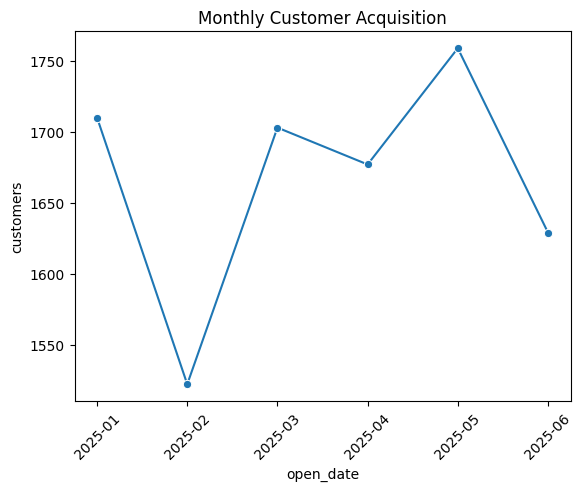

In [11]:
# Question 1: Are customers joining consistently?
from matplotlib import pyplot as plt

monthly_customers = (
    bank_data.groupby(bank_data["open_date"].dt.to_period("M"))
    .size()
    .reset_index(name="customers")
)

monthly_customers["open_date"] = monthly_customers["open_date"].astype(str)

sns.lineplot(data=monthly_customers, x="open_date", y="customers", marker="o")
plt.xticks(rotation=45)
plt.title("Monthly Customer Acquisition")
plt.show()

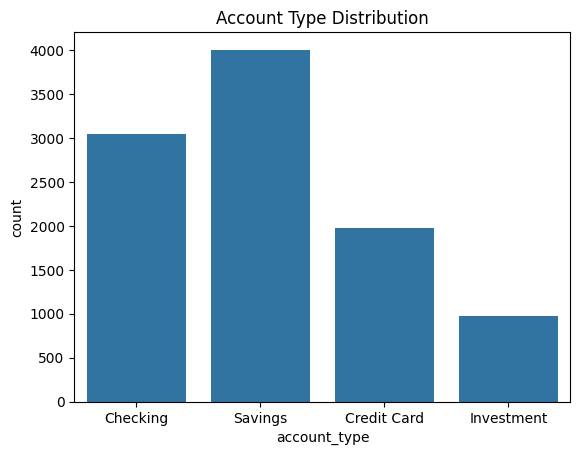

In [12]:
# Question 2: Which account type dominates?
account_counts = bank_data["account_type"].value_counts().reset_index()

sns.countplot(data=bank_data, x="account_type")
plt.title("Account Type Distribution")
plt.show()

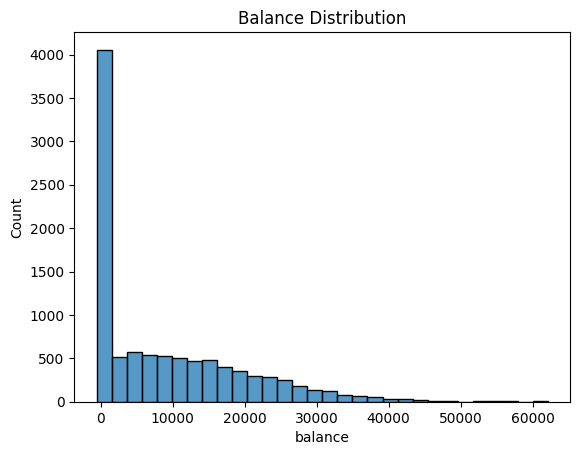

In [13]:
# Question 3: How much money does the bank hold?
total_balance = bank_data["balance"].sum()
average_balance = bank_data["balance"].mean()
median_balance = bank_data["balance"].median()

sns.histplot(bank_data["balance"], bins=30)
plt.title("Balance Distribution")
plt.show()

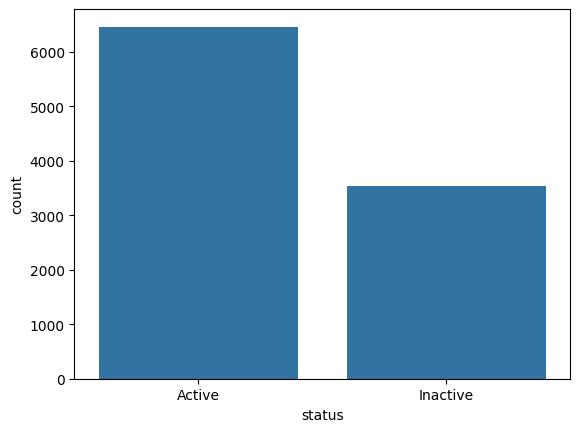

In [14]:
# Question 4: How many inactive customers exist?
inactive = (bank_data["balance"] == 0).sum()
inactive_percent = (bank_data["balance"] == 0).mean() * 100
bank_data["status"] = bank_data["balance"].apply(
    lambda x: "Inactive" if x == 0 else "Active"
)

sns.countplot(data=bank_data, x="status")
plt.show()

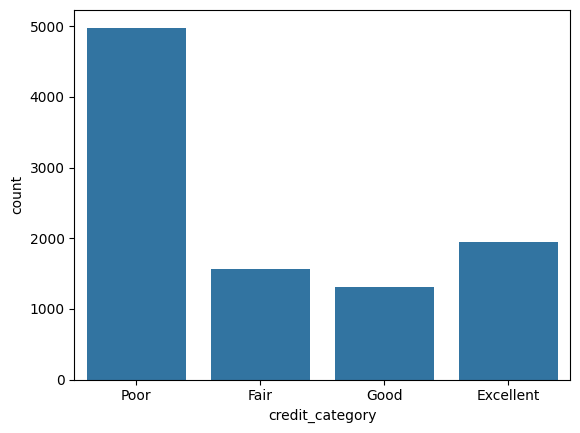

In [15]:
# Question 5: What is customer credit quality?
bins = [300, 580, 670, 740, 850]

labels = ["Poor", "Fair", "Good", "Excellent"]

bank_data["credit_category"] = pd.cut(
    bank_data["credit_score"], bins=bins, labels=labels
)

sns.countplot(data=bank_data, x="credit_category")
plt.show()

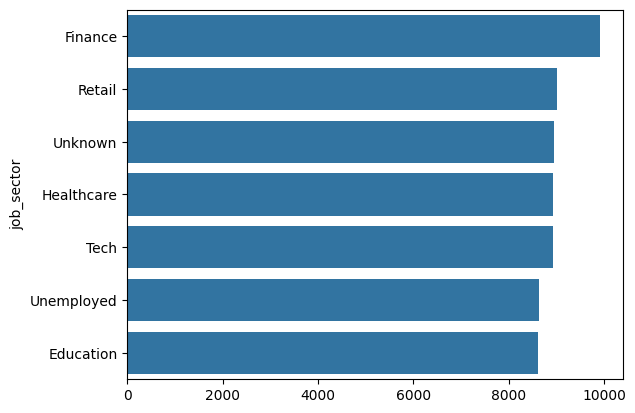

In [16]:
# Question 6: Which job sector is valuable?
sector_balance = (
    bank_data.groupby("job_sector")["balance"].mean().sort_values(ascending=False)
)

sns.barplot(x=sector_balance.values, y=sector_balance.index)
plt.show()

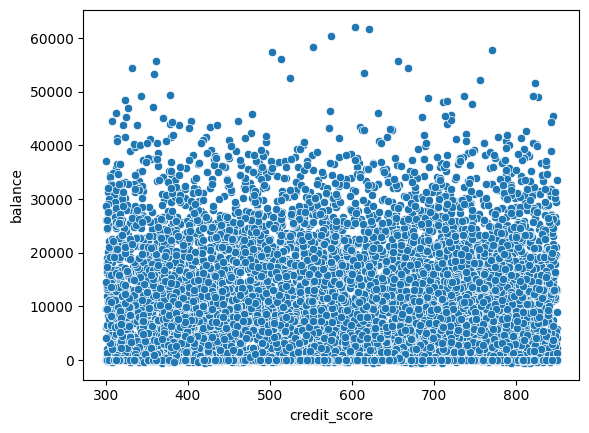

In [17]:
# Question 7: Is credit score related to balance?
correlation = bank_data["credit_score"].corr(bank_data["balance"])

sns.scatterplot(data=bank_data, x="credit_score", y="balance")
plt.show()

In [18]:
print("Customers:", len(bank_data))
print("Total Balance:", bank_data["balance"].sum())
print("Average Balance:", bank_data["balance"].mean())
print("Average Credit:", bank_data["credit_score"].mean())
print("Inactive %:", (bank_data["balance"] == 0).mean() * 100)

Customers: 10000
Total Balance: 89805408.94
Average Balance: 8980.540894
Average Credit: 576.0391836734694
Inactive %: 35.36
